In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pickle

In [73]:
df = pd.read_csv("E-Commerce Customer Insights and Churn Dataset3938d09.csv")


In [74]:
df["Sales"] = df["unit_price"] * df["quantity"]

In [75]:
date_col = "last_purchase_date"
sales_col = "Sales"

In [76]:
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col, sales_col])

In [77]:
daily_sales = df.groupby(date_col)[sales_col].sum().asfreq("D").fillna(0)

In [78]:
train_size = int(len(daily_sales) * 0.8)
train, test = daily_sales[:train_size], daily_sales[train_size:]

In [79]:
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7))
model_fit = model.fit(disp=False)

c:\Users\sudha\OneDrive\Desktop\churn\churn-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [80]:
pred = model_fit.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

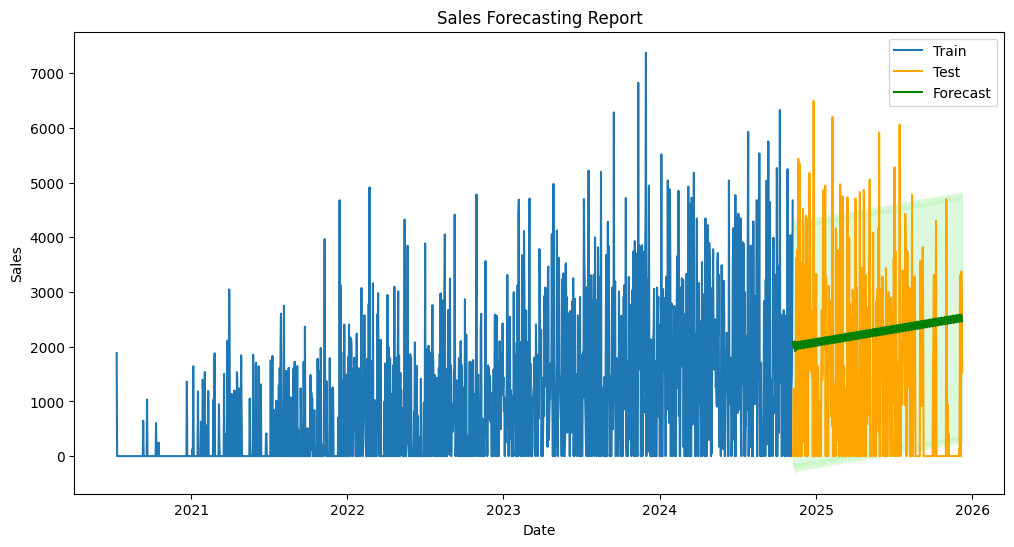

In [81]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="orange")
plt.plot(pred_mean.index, pred_mean, label="Forecast", color="green")
plt.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color="lightgreen", alpha=0.3)
plt.title("Sales Forecasting Report")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

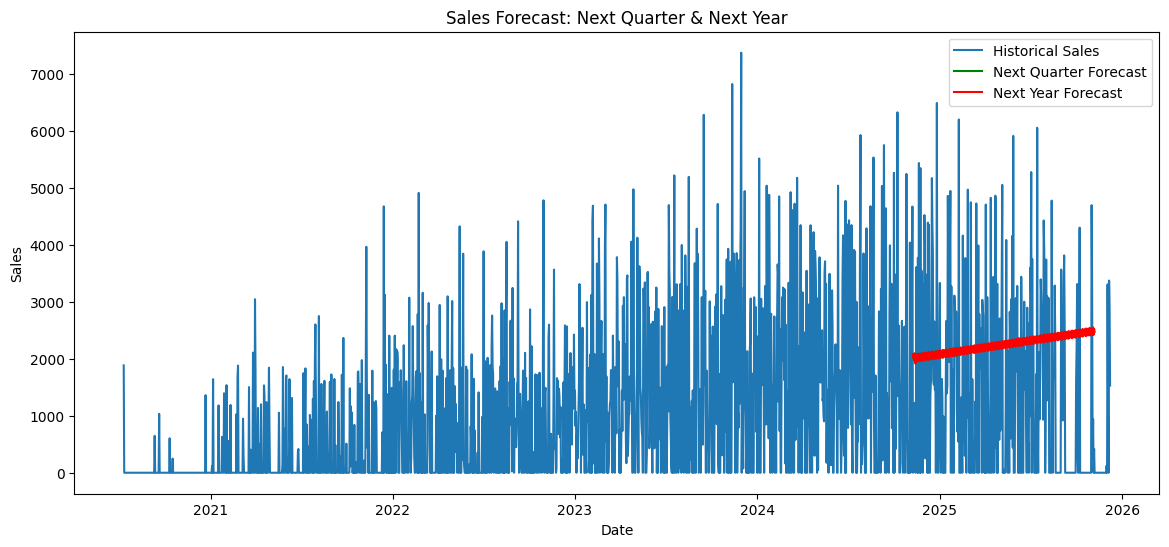

In [83]:
future_quarter = model_fit.get_forecast(steps=90)
future_year = model_fit.get_forecast(steps=365)

future_quarter_sales = future_quarter.predicted_mean
future_year_sales = future_year.predicted_mean
plt.figure(figsize=(14,6))
plt.plot(daily_sales.index, daily_sales, label="Historical Sales")
plt.plot(future_quarter_sales.index, future_quarter_sales, label="Next Quarter Forecast", color="green")
plt.plot(future_year_sales.index, future_year_sales, label="Next Year Forecast", color="red")
plt.title("Sales Forecast: Next Quarter & Next Year")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [84]:
product_sales = df.groupby("product_name")["Sales"].sum().sort_values(ascending=False)
top10_products = product_sales.head(10)
print("Top 10 Products by Historical Sales:\n", top10_products)
product_forecast = {}
for product in top10_products.index:
    prod_daily = df[df["product_name"]==product].set_index("last_purchase_date").resample("D")["Sales"].sum().fillna(0)
    model = SARIMAX(prod_daily, order=(1,1,1), seasonal_order=(1,1,1,7))
    model_fit = model.fit(disp=False)
    forecast = model_fit.get_forecast(steps=90).predicted_mean
    product_forecast[product] = forecast.sum()
top10_predicted = pd.Series(product_forecast).sort_values(ascending=False)
print("\nTop 10 Products by Predicted Sales (Next Quarter):\n", top10_predicted)

Top 10 Products by Historical Sales:
 product_name
Sneakers       75622.14
Skirt          69781.61
Dumbbells      66956.52
Smartphone     58772.23
Lipstick       58218.68
Cricket Bat    57986.18
Shirt          57910.03
Perfume        56164.26
Jacket         56094.67
Camera         55719.73
Name: Sales, dtype: float64

Top 10 Products by Predicted Sales (Next Quarter):
 Skirt          6980.037406
Dumbbells      6367.845738
Cricket Bat    5427.560395
Sneakers       5419.438075
Smartphone     5383.501904
Shirt          4823.957948
Lipstick       4679.059666
Perfume        4325.974490
Camera         3734.317032
Jacket         3633.955681
dtype: float64


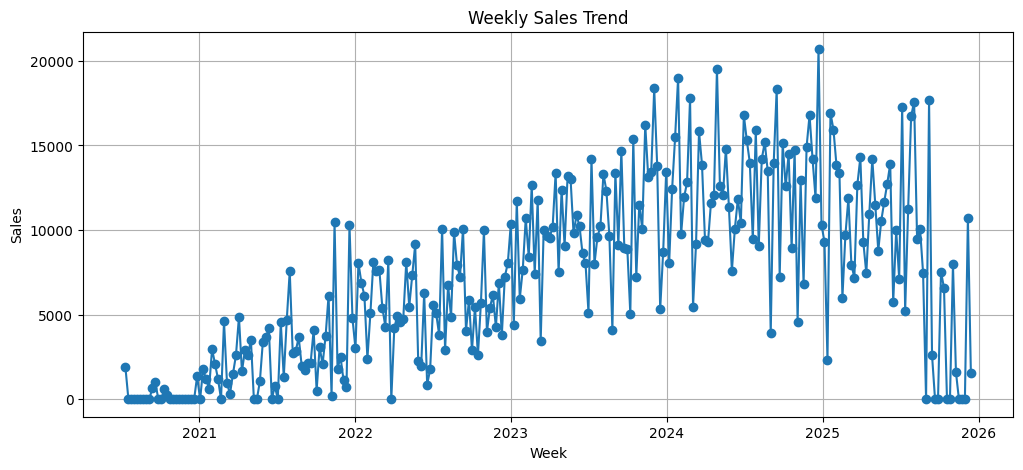


High Sales Weeks: 
 last_purchase_date
2023-01-15    11738.05
2023-02-19    12636.91
2023-03-05    11772.60
2023-04-16    13361.05
2023-04-30    12395.92
                ...   
2025-06-08    13914.74
2025-07-06    17255.79
2025-07-27    16719.12
2025-08-03    17592.26
2025-09-07    17681.35
Name: Sales, Length: 71, dtype: float64

Low Sales Weeks: 
 last_purchase_date
2020-07-12    1884.12
2020-07-19       0.00
2020-07-26       0.00
2020-08-02       0.00
2020-08-09       0.00
               ...   
2025-11-09    1600.46
2025-11-16       0.00
2025-11-23       0.00
2025-11-30       0.00
2025-12-14    1529.00
Name: Sales, Length: 71, dtype: float64


In [85]:
weekly_sales = daily_sales.resample("W").sum()
plt.figure(figsize=(12,5))
plt.plot(weekly_sales.index, weekly_sales, marker='o')
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.grid(True)
plt.show()
high_sales = weekly_sales[weekly_sales >= weekly_sales.quantile(0.75)]
low_sales = weekly_sales[weekly_sales <= weekly_sales.quantile(0.25)]

print("\nHigh Sales Weeks: \n",high_sales)
print("\nLow Sales Weeks: \n",low_sales)

In [86]:
inventory_forecast = {}
products = df["product_name"].unique()
for product in products:
    prod_data = df[df["product_name"]==product]
    prod_daily = prod_data.set_index("last_purchase_date").resample("D")["quantity"].sum().fillna(0)
    if len(prod_daily) < 30: 
        continue
    model = SARIMAX(prod_daily, order=(1,1,1), seasonal_order=(1,1,1,7))
    model_fit = model.fit(disp=False)
    forecast_qty = model_fit.get_forecast(steps=30).predicted_mean
    category = prod_data["category"].mode()[0]
    inventory_forecast[product] = {"category": category, "predicted_quantity": float(forecast_qty.sum())}

inventory_forecast_df = pd.DataFrame([
    {"Category": v["category"], "Product": k, "Predicted_Quantity_Next_30Days": v["predicted_quantity"]}
    for k, v in inventory_forecast.items()
])
inventory_forecast_df = inventory_forecast_df.sort_values(by="Predicted_Quantity_Next_30Days", ascending=False).reset_index(drop=True)
print(inventory_forecast_df.head(10))


      Category        Product  Predicted_Quantity_Next_30Days
0       Beauty        Shampoo                       11.999583
1     Clothing         Hoodie                        9.364293
2     Clothing          Skirt                        9.228452
3       Sports      Dumbbells                        8.712401
4       Beauty    Moisturizer                        8.341053
5       Sports  Running Shoes                        8.010418
6         Home           Lamp                        7.922849
7       Sports    Cricket Bat                        7.687958
8       Beauty       Lipstick                        7.309826
9  Electronics     Headphones                        7.277525


In [87]:
with open("sales forcecast model.pkl","wb") as f:
    pickle.dump(model_fit,f)